In [2]:
from fh_script import * 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy 
import cmocean 
import cartopy.crs as ccrs 
import cartopy.feature as cfeature

Notebook dedicated to study the Lofoten Vortex with the use of f/h contours. Aim is to check whether Inference results capture this vortex / eddy that is constant in the Lofoten Basin. 

In [3]:
""" 
Start of with just a resample of one day for simplicity
"""
"""
path_to_inf = '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42'
checkpoint = '2024-03-30_24h_18d28_e011_s049990.nc'
ds = xr.open_dataset(f'{path_to_inf}/{checkpoint}') #.resample(time = '1D').mean()
""" 

norkyst_p = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240402.nc'
ds = xr.open_dataset(norkyst_p)


In [17]:
print(f"Longitude min: {ds.lon.min()}, Longitude max: {ds.lon.max()}")
print(f"Latitude min: {ds.lat.min()}, Latitude max: {ds.lat.max()}")

Longitude min: <xarray.DataArray 'lon' ()> Size: 8B
array(-4.61489652), Longitude max: <xarray.DataArray 'lon' ()> Size: 8B
array(37.55453838)
Latitude min: <xarray.DataArray 'lat' ()> Size: 8B
array(54.29489733), Latitude max: <xarray.DataArray 'lat' ()> Size: 8B
array(75.72596758)


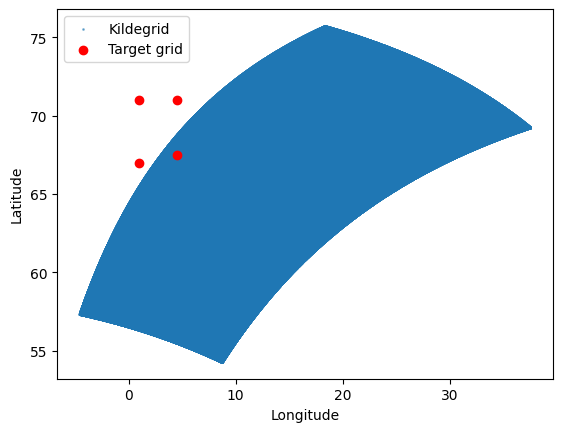

In [20]:
import matplotlib.pyplot as plt

# Visualiser kildegridet
plt.scatter(ds.lon.values.flatten(), ds.lat.values.flatten(), s=1, label="Kildegrid", alpha=0.5)

# Visualiser target-gridet
plt.scatter([1.0, 4.5, 4.5, 1.0], [67.0, 67.5, 71.0, 71.0], color="red", label="Target grid", zorder=5)

plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [4]:
import pyresample
#select an area

lon_ulc, lon_llc = 8.0, 8.0
lon_lrc, lon_urc = 12, 12
lat_urc, lat_ulc = 71, 71
lat_llc, lat_lrc = 67, 67.5

"""
lon_re = ds.longitude.astype(np.float64)
lat_re = ds.latitude.astype(np.float64)
"""

ds_grid = pyresample.geometry.GridDefinition(lons=ds.lon.values, lats = ds.lat.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 1500,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape) 

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')


X min: 733, X max: 1134
Y min: 1532, Y max: 2094


In [14]:
import pyresample
#select an area
#lon_min, lon_max = 11.83083, 15.59072
#lat_min, lat_max = 67.41791, 69.20699

lon_ulc, lon_llc = 7.8, 7.8
lon_lrc, lon_urc = 12.0, 12.0
lat_urc, lat_ulc = 71.0, 71.0
lat_llc, lat_lrc = 67.0, 67.0

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid = pyresample.geometry.GridDefinition(lons=ds.lon.values, lats = ds.lat.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')



X min: 697, X max: 1141
Y min: 1527, Y max: 2094


In [6]:
print(ds.longitude.values)

AttributeError: 'Dataset' object has no attribute 'longitude'